# 3D CNN Models — Hand Gesture Recognition

Two models trained directly on raw-pixel video clips from `03_clip_extraction.ipynb`:
1. **Model A** - a compact 3D CNN (Conv3D stack) trained from scratch
2. **Model B** - pretrained R(2+1)D-18 (Kinetics-400), fine-tuned

Both are evaluated with the shared `src/evaluation/metrics.py` module so results are
directly comparable to the landmark-based branche.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.dataset import GESTURE_NAMES, NUM_CLASSES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.video_dataset import (
    GestureClipDataset, stratified_train_val_split, compute_class_weights,
    IMAGENET_MEAN, IMAGENET_STD, KINETICS_MEAN, KINETICS_STD,
)
from src.models.train_utils import get_device
from src.models.train_utils import train_model, plot_history, predict

CLIP_DIR = "../data/processed"

DEVICE = get_device()  # MPS > CUDA > CPU
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Dataset & DataLoader

Stratified train/val split carved out of the train metadata only (test stays untouched,
official split). 

Class weights are computed from the train split for the weighted loss.

In [2]:
train_df, val_df = stratified_train_val_split(
    f"{CLIP_DIR}/train/_metadata.csv", val_frac=0.15, seed=42
)
print(f"Train: {len(train_df)}   Val: {len(val_df)}")

class_weights = compute_class_weights(train_df, num_classes=NUM_CLASSES)
print("\nClass weights (balanced: N / (num_classes * count)):")
for name, w in zip(GESTURE_NAMES, class_weights):
    print(f"  {name:14s} {w:.3f}")

Train: 2649   Val: 468

Class weights (balanced: N / (num_classes * count)):
  Point-1f       0.322
  Point-2f       0.323
  Click-1f       1.617
  Click-2f       1.617
  Throw-up       1.617
  Throw-down     1.617
  Throw-left     1.617
  Throw-right    1.617
  Open-twice     1.617
  DblClick-1f    1.630
  DblClick-2f    1.617
  Zoom-in        1.617
  Zoom-out       1.617


In [3]:
BATCH_SIZE = 8

# ImageNet stats for the from-scratch model (Model B will use its own
# Kinetics-normalized loaders).
train_ds = GestureClipDataset(train_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=True)
val_ds = GestureClipDataset(val_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)
test_ds = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}   Test batches: {len(test_loader)}")

Train batches: 332   Val batches: 59   Test batches: 138


## 2. Sanity check — inspect a batch

In [4]:
clips, labels = next(iter(train_loader))
print(f"Batch clips shape:  {clips.shape}")   # expect (B, 3, 16, 112, 112)
print(f"Batch labels shape: {labels.shape}")
print(f"dtype: {clips.dtype}, value range: [{clips.min():.3f}, {clips.max():.3f}]")
print(f"Labels: {labels.tolist()}")

Batch clips shape:  torch.Size([8, 3, 16, 112, 112])
Batch labels shape: torch.Size([8])
dtype: torch.float32, value range: [-2.118, 2.640]
Labels: [1, 1, 0, 1, 0, 5, 8, 12]


## 3. Visualize a clip — raw vs. augmented

Confirms the augmentation pipeline (flip / crop jitter / temporal jitter / color jitter)
is doing something reasonable.

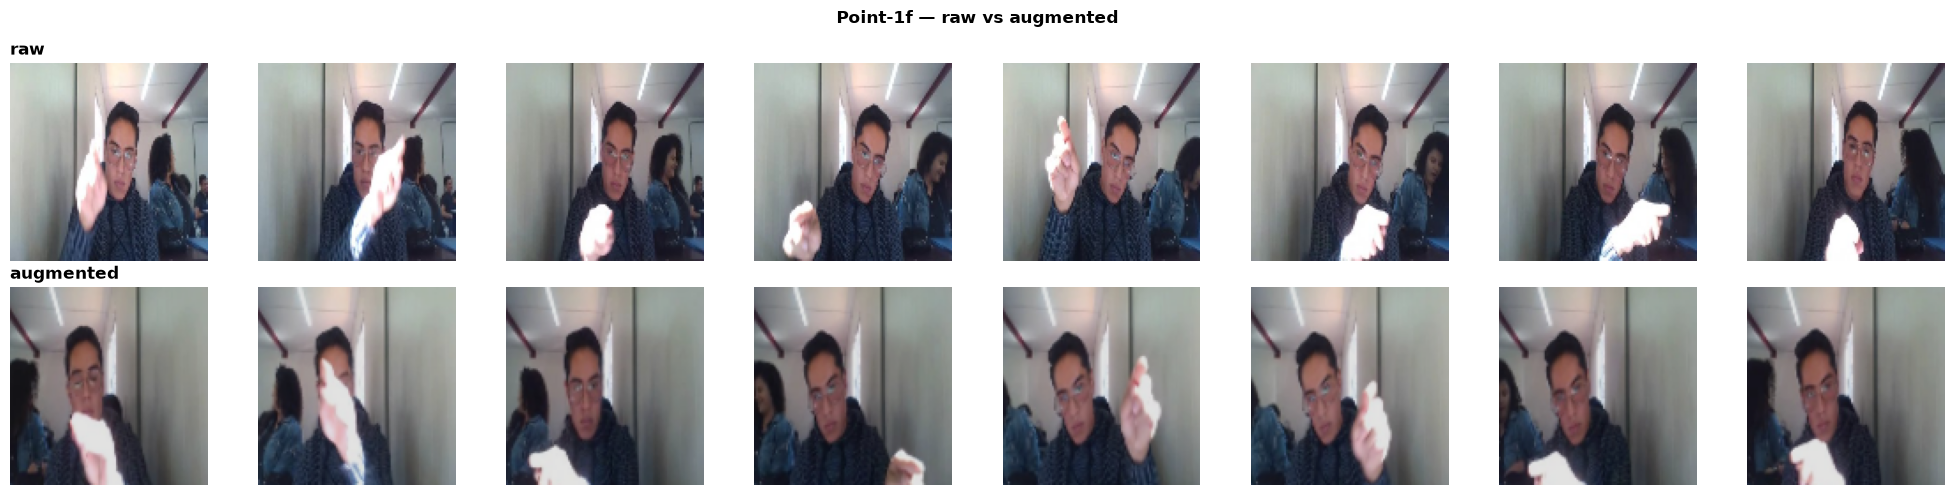

In [5]:
def denormalize(clip_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """(3, T, H, W) normalized tensor -> (T, H, W, 3) uint8 for display."""
    clip = clip_tensor.numpy() * std.reshape(3, 1, 1, 1) + mean.reshape(3, 1, 1, 1)
    clip = np.clip(clip, 0, 1)
    clip = np.transpose(clip, (1, 2, 3, 0))  # (T, H, W, 3)
    return (clip * 255).astype(np.uint8)


idx = 0
raw_clip = np.load(train_df.iloc[idx]['npy_path'])
aug_clip_t, label = train_ds[idx]
aug_clip = denormalize(aug_clip_t)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(raw_clip[i * 2]); axes[0, i].axis('off')
    axes[1, i].imshow(aug_clip[i * 2]); axes[1, i].axis('off')
axes[0, 0].set_title("raw", loc='left', fontweight='bold')
axes[1, 0].set_title("augmented", loc='left', fontweight='bold')
plt.suptitle(f"{train_df.iloc[idx]['gesture_name']} — raw vs augmented", fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model A — 3D CNN from scratch

A compact Conv3D stack, kept small so it trains in reasonable time on MPS:

```
(3,16,112,112) → Conv3D(3→32)  + BN + ReLU + MaxPool3D(2)
               → Conv3D(32→64) + BN + ReLU + MaxPool3D(2)
               → Conv3D(64→128)+ BN + ReLU + MaxPool3D(2)
               → Conv3D(128→256)+BN + ReLU + AdaptiveAvgPool3D(1)
               → FC(256→128) + ReLU + Dropout(0.5) → FC(128→13)
```

In [6]:
from src.models.cnn3d import Simple3DCNN

model_a = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model_a.parameters())
n_trainable = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Model A parameters: {n_params:,} total, {n_trainable:,} trainable")

# Forward-pass sanity check on a real batch, on-device.
clips, labels = next(iter(train_loader))
with torch.no_grad():
    logits = model_a(clips.to(DEVICE))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {logits.shape}")   # expect (B, 13)

Model A parameters: 1,199,821 total, 1,199,821 trainable
Input shape:  torch.Size([8, 3, 16, 112, 112])
Output shape: torch.Size([8, 13])


## 4b. Learning rate sweep — Model A

- Systematically compare learning rates before the final training run.
- Each lr trains a fresh Simple3DCNN for a fixed number of epochs; we compare validation accuracy. This documents the lr choice instead of picking it blindly.

In [7]:
LR_GRID = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4]
SWEEP_EPOCHS = 10         
SWEEP_PATIENCE = SWEEP_EPOCHS 

sweep_histories = {}       # lr -> history dict

for lr in LR_GRID:
    print(f"\n{'='*55}\n  Learning rate: {lr}\n{'='*55}")
    torch.manual_seed(42)                       # same init for a fair comparison
    model_sweep = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)

    criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.Adam(model_sweep.parameters(), lr=lr)
    # No scheduler during the sweep, so each lr is judged at its set value

    history, _ = train_model(
        model_sweep, train_loader, val_loader, criterion, optimizer, DEVICE,
        num_epochs=SWEEP_EPOCHS, patience=SWEEP_PATIENCE, scheduler=None,
        checkpoint_path=f"../data/checkpoints/sweep_lr_{lr}.pth",
        model_name=f"sweep_lr_{lr}",
    )
    sweep_histories[lr] = history


  Learning rate: 0.01
[sweep_lr_0.01] epoch   1/10 | train_loss 2.5570 acc 0.1570 | val_loss 2.4590 acc 0.2244 | 198.2s
[sweep_lr_0.01] epoch   2/10 | train_loss 2.4417 acc 0.1925 | val_loss 2.4265 acc 0.1688 | 253.8s
[sweep_lr_0.01] epoch   3/10 | train_loss 2.3798 acc 0.2061 | val_loss 2.2671 acc 0.2457 | 262.7s
[sweep_lr_0.01] epoch   4/10 | train_loss 2.3283 acc 0.2405 | val_loss 2.3052 acc 0.2436 | 263.5s
[sweep_lr_0.01] epoch   5/10 | train_loss 2.3125 acc 0.2393 | val_loss 2.2030 acc 0.2799 | 270.6s
[sweep_lr_0.01] epoch   6/10 | train_loss 2.2798 acc 0.2367 | val_loss 2.1542 acc 0.2991 | 249.7s
[sweep_lr_0.01] epoch   7/10 | train_loss 2.2542 acc 0.2458 | val_loss 2.2433 acc 0.2308 | 263.1s
[sweep_lr_0.01] epoch   8/10 | train_loss 2.2529 acc 0.2495 | val_loss 2.1716 acc 0.2222 | 331.2s
[sweep_lr_0.01] epoch   9/10 | train_loss 2.2437 acc 0.2276 | val_loss 2.0851 acc 0.3034 | 694.1s
[sweep_lr_0.01] epoch  10/10 | train_loss 2.2285 acc 0.2431 | val_loss 2.1576 acc 0.2863 | 481.

### Plot 1 — validation accuracy curves per learning rate

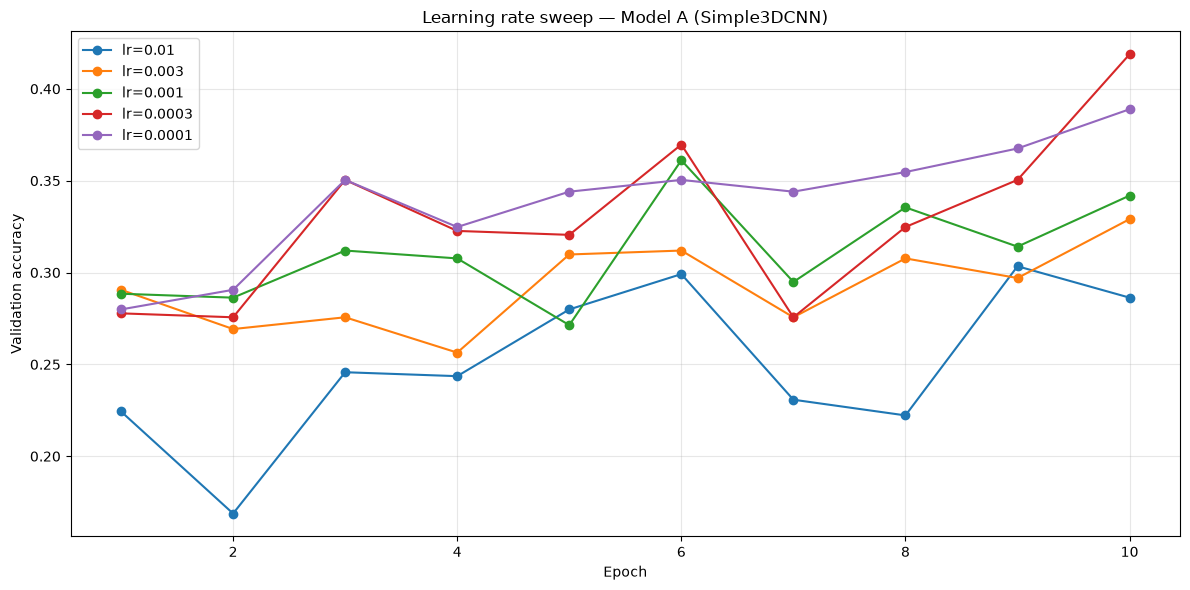

In [8]:
plt.figure(figsize=(12, 6))
for lr, hist in sweep_histories.items():
    # train_model histories usually store 'val_acc'; adjust key if yours differs
    val_accs = hist['val_acc'] if 'val_acc' in hist else hist['val_accuracy']
    plt.plot(range(1, len(val_accs) + 1), val_accs, marker='o', label=f"lr={lr}")
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('Learning rate sweep — Model A (Simple3DCNN)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/lr_sweep_curves_modelA.png", dpi=150, bbox_inches='tight')
plt.show()

### Plot 2 — best validation accuracy vs learning rate

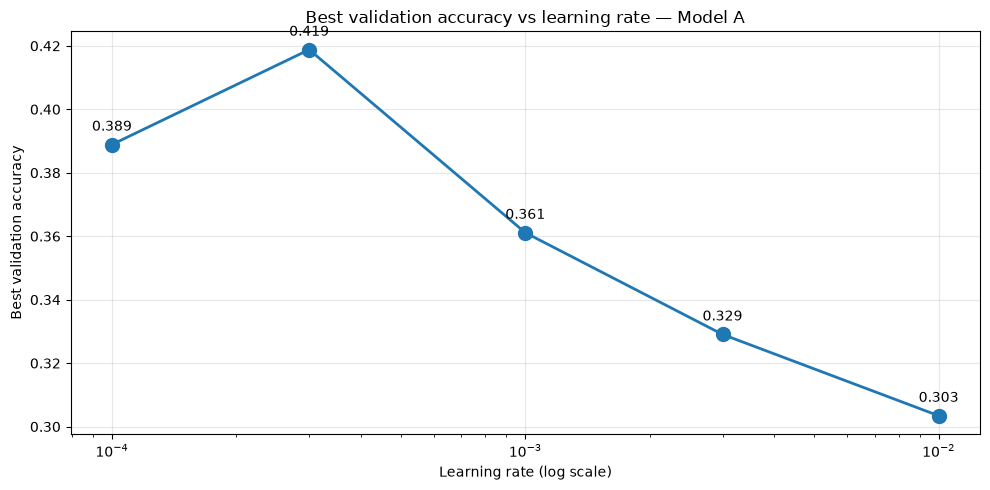

In [9]:
def best_val(hist):
    accs = hist['val_acc'] if 'val_acc' in hist else hist['val_accuracy']
    return max(accs)

best_per_lr = {lr: best_val(h) for lr, h in sweep_histories.items()}

plt.figure(figsize=(10, 5))
lrs = list(best_per_lr.keys())
vals = list(best_per_lr.values())
plt.semilogx(lrs, vals, marker='o', markersize=10, linewidth=2)
for lr, v in best_per_lr.items():
    plt.annotate(f"{v:.3f}", (lr, v), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xlabel('Learning rate (log scale)')
plt.ylabel('Best validation accuracy')
plt.title('Best validation accuracy vs learning rate — Model A')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/lr_sweep_best_modelA.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
best_lr_a = max(best_per_lr, key=best_per_lr.get)
print(f"Best learning rate: {best_lr_a}  (val acc {best_per_lr[best_lr_a]:.3f})\n")
print("Ranking:")
for lr, v in sorted(best_per_lr.items(), key=lambda x: -x[1]):
    print(f"  lr={lr:<8} best val acc {v:.3f}")

Best learning rate: 0.0003  (val acc 0.419)

Ranking:
  lr=0.0003   best val acc 0.419
  lr=0.0001   best val acc 0.389
  lr=0.001    best val acc 0.361
  lr=0.003    best val acc 0.329
  lr=0.01     best val acc 0.303


## 5. Training loop — Model A

- Weighted CrossEntropyLoss (class weights from step 1)
- Adam 
- ReduceLROnPlateau
- Early stopping on val loss (patience 10)

In [11]:
from src.models.train_utils import train_model, plot_history, predict

NUM_EPOCHS = 50
PATIENCE = 10

criterion_a = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer_a = torch.optim.Adam(model_a.parameters(), lr=best_lr_a)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode='min', factor=0.5, patience=4)

history_a, model_a = train_model(
    model_a, train_loader, val_loader, criterion_a, optimizer_a, DEVICE,
    num_epochs=NUM_EPOCHS, patience=PATIENCE, scheduler=scheduler_a,
    checkpoint_path="../data/checkpoints/model_a_scratch_best.pth",
    model_name="3DCNN_scratch",
)

[3DCNN_scratch] epoch   1/50 | train_loss 2.3851 acc 0.2431 | val_loss 2.2127 acc 0.3184 | 241.7s
[3DCNN_scratch] epoch   2/50 | train_loss 2.2549 acc 0.2831 | val_loss 2.1922 acc 0.3162 | 272.5s
[3DCNN_scratch] epoch   3/50 | train_loss 2.1865 acc 0.2801 | val_loss 2.0887 acc 0.3013 | 270.9s
[3DCNN_scratch] epoch   4/50 | train_loss 2.1245 acc 0.3028 | val_loss 2.0100 acc 0.3269 | 282.2s
[3DCNN_scratch] epoch   5/50 | train_loss 2.0736 acc 0.3084 | val_loss 1.9579 acc 0.3462 | 252.4s
[3DCNN_scratch] epoch   6/50 | train_loss 2.0098 acc 0.3073 | val_loss 2.0693 acc 0.2885 | 268.7s
[3DCNN_scratch] epoch   7/50 | train_loss 1.9466 acc 0.3277 | val_loss 1.8173 acc 0.3697 | 266.0s
[3DCNN_scratch] epoch   8/50 | train_loss 1.8959 acc 0.3382 | val_loss 1.9194 acc 0.2885 | 260.4s
[3DCNN_scratch] epoch   9/50 | train_loss 1.8399 acc 0.3443 | val_loss 1.9635 acc 0.3162 | 254.9s
[3DCNN_scratch] epoch  10/50 | train_loss 1.7664 acc 0.3809 | val_loss 2.0813 acc 0.3312 | 251.4s
[3DCNN_scratch] epoc

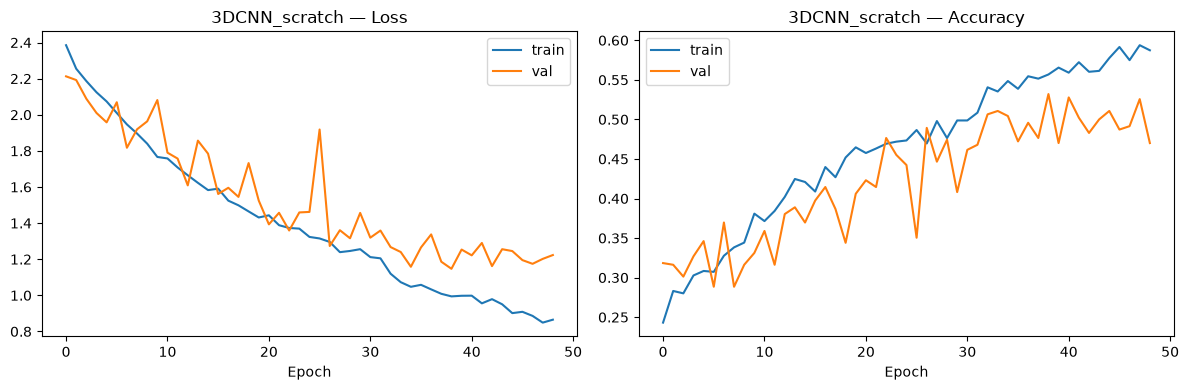

In [12]:
plot_history(history_a, "3DCNN_scratch")

### Resuming without retraining

If the kernel restarts (or you just don't want to wait ~3.7 hours again), skip the
training cell above and run this instead — it loads the already-trained weights
straight from the checkpoint saved during that run

In [13]:
model_a.load_state_dict(torch.load("../data/checkpoints/model_a_scratch_best.pth", map_location=DEVICE))
model_a.eval()
print("Loaded Model A from checkpoint (no training needed).")

Loaded Model A from checkpoint (no training needed).


## 6. Evaluate Model A on the test set


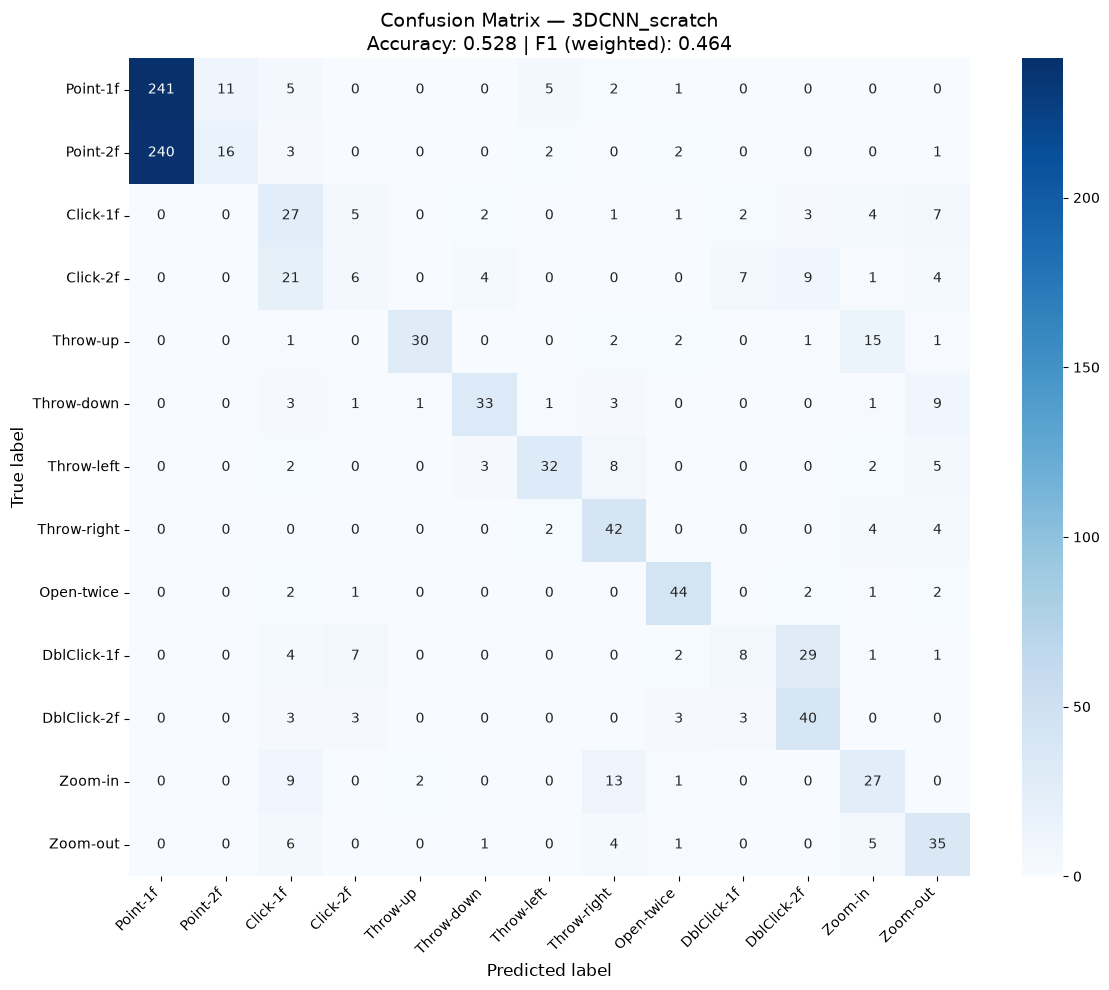

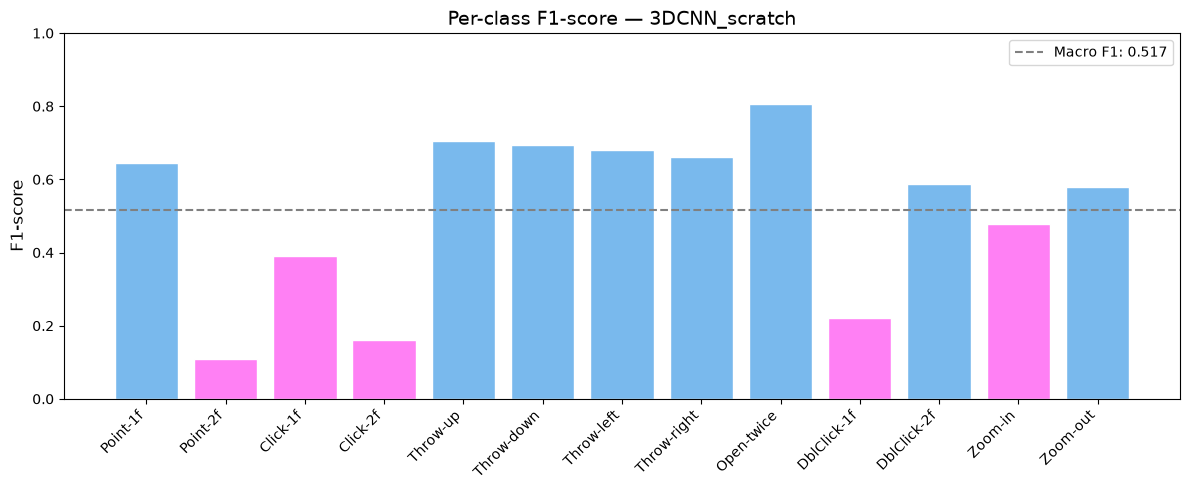


  3DCNN_scratch — Results
  Accuracy:          0.5277
  F1 (weighted):     0.4638
  F1 (macro):        0.5173
  Precision (w):     0.5542
  Recall (w):        0.5277
  Top-3 Accuracy:    0.9246
  Top-5 Accuracy:    0.9637

              precision    recall  f1-score   support

    Point-1f       0.50      0.91      0.65       265
    Point-2f       0.59      0.06      0.11       264
    Click-1f       0.31      0.52      0.39        52
    Click-2f       0.26      0.12      0.16        52
    Throw-up       0.91      0.58      0.71        52
  Throw-down       0.77      0.63      0.69        52
  Throw-left       0.76      0.62      0.68        52
 Throw-right       0.56      0.81      0.66        52
  Open-twice       0.77      0.85      0.81        52
 DblClick-1f       0.40      0.15      0.22        52
 DblClick-2f       0.48      0.77      0.59        52
     Zoom-in       0.44      0.52      0.48        52
    Zoom-out       0.51      0.67      0.58        52

    accuracy      

In [14]:
y_true_a, y_pred_a, y_prob_a = predict(model_a, test_loader, DEVICE)

results_a = full_evaluation(
    y_true_a, y_pred_a, "3DCNN_scratch",
    save_dir="../results/figures", y_prob=y_prob_a
)

In [15]:
from src.models.train_utils import count_parameters

def model_a_predict_fn(x):
    with torch.no_grad():
        return model_a(x)

sample_clip, _ = test_ds[0]
sample_clip = sample_clip.unsqueeze(0).to(DEVICE)  # (1, 3, 16, 112, 112)

timing_a = measure_inference_time(model_a_predict_fn, sample_clip, n_runs=100)
n_params_a, n_trainable_a = count_parameters(model_a)

print(f"Model A — {n_params_a:,} parameters")
print(f"Inference: {timing_a['mean_ms']:.2f} ± {timing_a['std_ms']:.2f} ms  ({timing_a['fps']:.1f} FPS)")

Model A — 1,199,821 parameters
Inference: 9.80 ± 6.42 ms  (102.0 FPS)


### Analysis — Model A: Simple3DCNN (from scratch)

**Learning rate tuning.**
 
Before the final training run, we performed a learning rate sweep to choose the starting learning rate systematically rather than by default. Five values were compared (`1e-2, 3e-3, 1e-3, 3e-4, 1e-4`), each training a fresh Simple3DCNN for 10 epochs with a fixed learning rate (no scheduler), and we recorded the best validation accuracy per rate:
 
| Learning rate | Best val accuracy (10 epochs) |
|---------------|-------------------------------|
| 3e-4          | **0.419** |
| 1e-4          | 0.389 |
| 1e-3          | 0.361 |
| 3e-3          | 0.329 |
| 1e-2          | 0.303 |
 
The result shows a clear monotonic trend: the higher the learning rate, the worse the model performs. This is typical for training from scratch on a small dataset — a large learning rate overshoots good solutions, so a moderately small rate (`3e-4`) works best, while `1e-4` learns slightly too slowly within 10 epochs. The final model was then trained to convergence (up to 50 epochs, `ReduceLROnPlateau` scheduler, early stopping on validation loss) with the winning learning rate `3e-4`.

**Overall:** 

Test accuracy **0.528**, weighted F1 **0.464**, macro F1 **0.517**. Top-3 accuracy is **0.925** and Top-5 is **0.964**. 

This is a solid result for a 3D CNN trained from scratch on only ~3,100 training clips. Test accuracy (50.6%) is close to validation accuracy (~52.8%), so the model generalizes well and does not overfit. The very high Top-3 accuracy shows the model almost always ranks the correct class among its top three guesses — it mostly hesitates between visually similar gestures rather than being completely wrong.

**A note on the weighted vs macro F1 gap.**
 
Unusually, the weighted F1 (0.464) is *lower* than the macro F1 (0.517). This is caused by the model's behaviour on the two dominant classes: it predicts almost all `Point` gestures as `Point-1f` (recall 0.91) while nearly abandoning `Point-2f` (recall 0.06, F1 0.11). Because `Point-2f` has 264 samples, its collapse drags the weighted F1 down heavily. This is a well-known failure mode when training from scratch on imbalanced data — the model finds a shortcut (predict the more convenient class) instead of learning the true one-finger-vs-two distinction. Even with class-weighted loss, the pixel features from scratch are not discriminative enough to prevent this. It is a good illustration of why higher accuracy does not always mean a better model, and why the pretrained model (below) is needed.

**Confusion matrix**
**Where the model fails:**

- **Point-2f collapse:** 240 of 264 `Point-2f` samples are predicted as `Point-1f` (only 16 correct). The model cannot tell one finger from two — a fine static detail that is hard to read from raw 112×112 pixels — and defaults to the more convenient class.

- **Click / DblClick confusion:** `Click-2f` is especially weak (only 6 of 52 correct), scattered across `Click-1f`, `DblClick-1f`, and `DblClick-2f`. These classes differ by a subtle motion and finger count.

- **Zoom-in:** only 27 of 52 correct, frequently confused with `Throw-right` (13) and `Click-1f` (9).

**Where the model succeeds:** 

- `Open-twice` (44/52), `Throw-right` (42/52), `Zoom-out` (35/52), and `DblClick-2f` (40/52) are the strongest classes. These involve larger, clearer motion over time — precisely what a 3D CNN captures well, in contrast to the static finger-count distinctions it struggles with.

**Summary:** 

3D CNN from scratch model discriminates gestures well by their *motion*, but poorly by fine *static* details such as finger count and on imbalanced data it is prone to collapsing a class. This motivates comparing it against (a) the pretrained R(2+1)D-18, whose richer Kinetics-400 features should help on the harder classes, and (b) the landmark-based models, which encode finger geometry explicitly.

In [16]:
import os, json

os.makedirs("../results", exist_ok=True)

summary_a = {
    'model': '3DCNN_scratch',
    'approach': 'raw video clip (3D CNN, from scratch)',
    'accuracy': float(results_a['accuracy']),
    'f1_weighted': float(results_a['f1_weighted']),
    'f1_macro': float(results_a['f1_macro']),
    'inference_ms': float(timing_a['mean_ms']),
    'parameters': int(n_params_a),
    'config': {'architecture': 'Conv3D x4 + FC head', 'batch_size': BATCH_SIZE,
               'num_epochs': 50, 'optimizer': 'Adam', 'lr': 1e-3,
               'dropout': 0.5, 'n_frames': 16, 'resolution': 112},
}

with open("../results/3dcnn_scratch_results.json", "w") as f:
    json.dump(summary_a, f, indent=2)

print(json.dumps(summary_a, indent=2))

{
  "model": "3DCNN_scratch",
  "approach": "raw video clip (3D CNN, from scratch)",
  "accuracy": 0.5277020890099909,
  "f1_weighted": 0.4637660233325228,
  "f1_macro": 0.5172658180447726,
  "inference_ms": 9.803982152370736,
  "parameters": 1199821,
  "config": {
    "architecture": "Conv3D x4 + FC head",
    "batch_size": 8,
    "num_epochs": 50,
    "optimizer": "Adam",
    "lr": 0.001,
    "dropout": 0.5,
    "n_frames": 16,
    "resolution": 112
  }
}


## 7. Model B — R(2+1)D-18 (trained on Google Colab)

A 31M-parameter pretrained video model is too slow to fine-tune on local MPS, so
this one trains on Google Colab's free GPU instead — see
[`07_colab_r2plus1d.ipynb`](07_colab_r2plus1d.ipynb) for the full self-contained script.

The architecture is defined here too (`src/models/r2plus1d.py`). Once training finishes there and the checkpoint is downloaded, it will be
loaded here for evaluation.

In [17]:
from src.models.r2plus1d import build_r2plus1d

model_b = build_r2plus1d(num_classes=NUM_CLASSES).to(DEVICE)

n_params_b = sum(p.numel() for p in model_b.parameters())
print(f"Model B (R(2+1)D-18) parameters: {n_params_b:,}")

# Forward-pass sanity check with Kinetics normalization
test_ds_b = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=KINETICS_MEAN, std=KINETICS_STD, train=False)
clips_b, labels_b = next(iter(DataLoader(test_ds_b, batch_size=4)))
with torch.no_grad():
    logits_b = model_b(clips_b.to(DEVICE))
print(f"Input shape:  {clips_b.shape}")
print(f"Output shape: {logits_b.shape}")   # expect (B, 13)

Model B (R(2+1)D-18) parameters: 31,306,794
Input shape:  torch.Size([4, 3, 16, 112, 112])
Output shape: torch.Size([4, 13])


## 8. Evaluate Model B

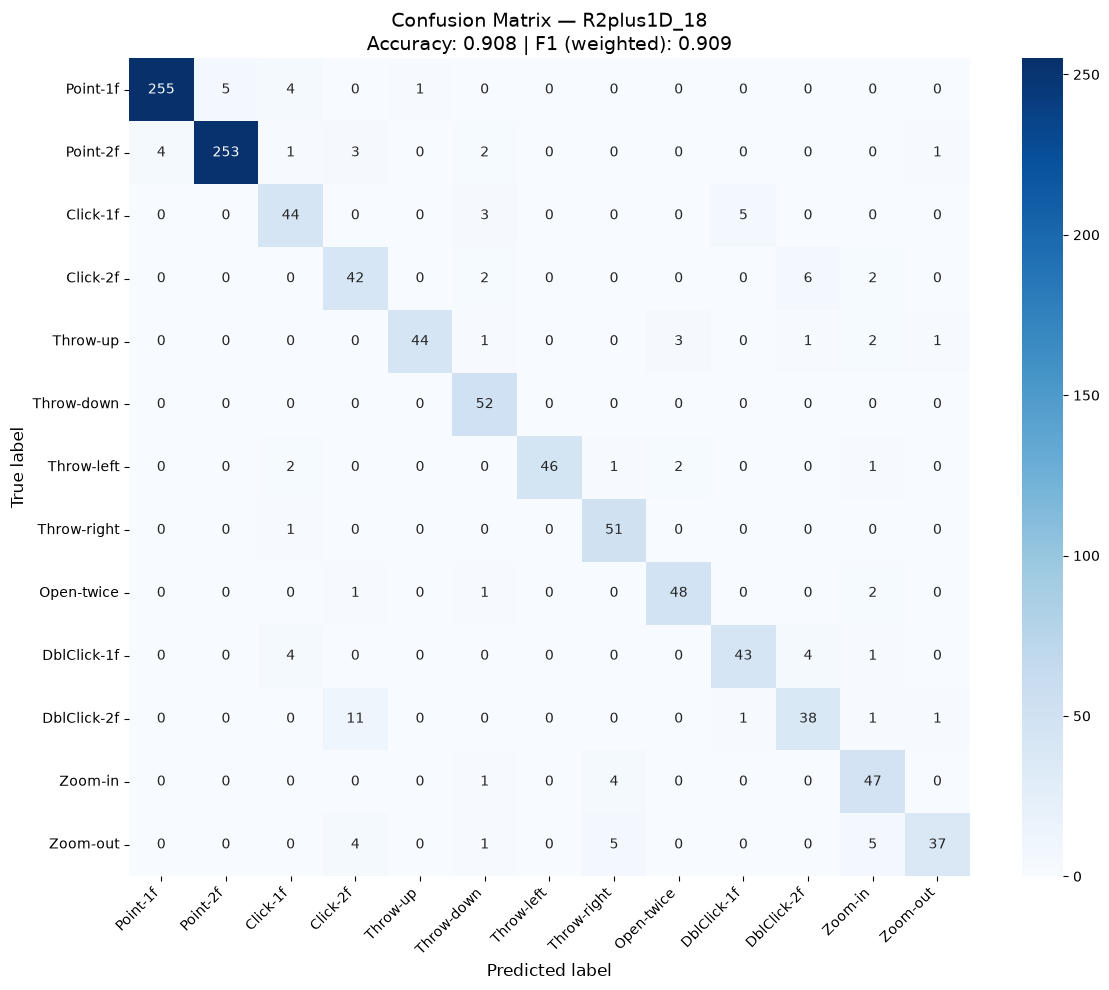

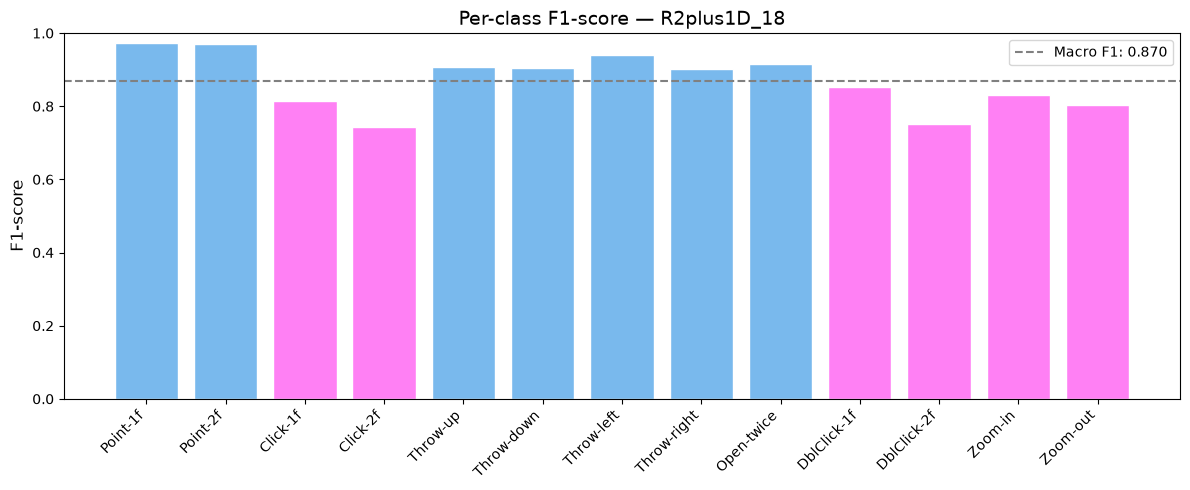


  R2plus1D_18 — Results
  Accuracy:          0.9083
  F1 (weighted):     0.9090
  F1 (macro):        0.8699
  Precision (w):     0.9145
  Recall (w):        0.9083
  Top-3 Accuracy:    0.9837
  Top-5 Accuracy:    0.9909

              precision    recall  f1-score   support

    Point-1f       0.98      0.96      0.97       265
    Point-2f       0.98      0.96      0.97       264
    Click-1f       0.79      0.85      0.81        52
    Click-2f       0.69      0.81      0.74        52
    Throw-up       0.98      0.85      0.91        52
  Throw-down       0.83      1.00      0.90        52
  Throw-left       1.00      0.88      0.94        52
 Throw-right       0.84      0.98      0.90        52
  Open-twice       0.91      0.92      0.91        52
 DblClick-1f       0.88      0.83      0.85        52
 DblClick-2f       0.78      0.73      0.75        52
     Zoom-in       0.77      0.90      0.83        52
    Zoom-out       0.93      0.71      0.80        52

    accuracy        

In [18]:
data = np.load("../results/predictions.npz")
results_b = full_evaluation(
    data['y_true'], data['y_pred'], "R2plus1D_18",
    save_dir="../results/figures", y_prob=data['y_prob']
)

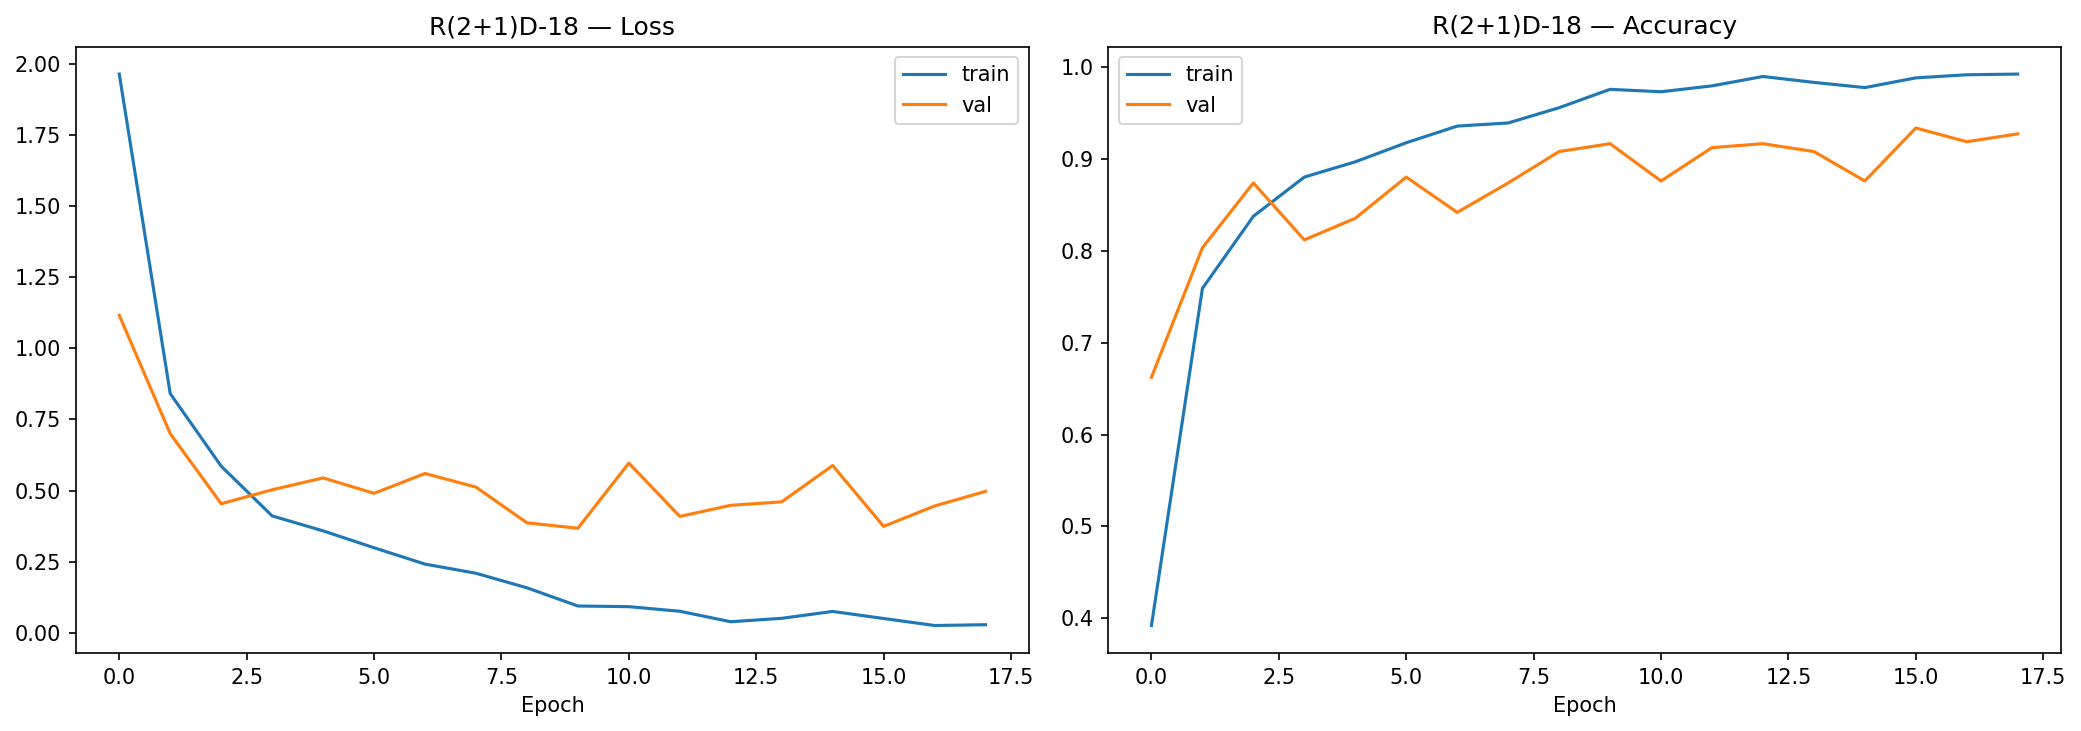

In [19]:
from IPython.display import Image
Image("../results/figures/history_r2plus1d.png")

In [20]:
model_b.load_state_dict(torch.load("../data/checkpoints/best_r2plus1d.pth", map_location=DEVICE))
model_b.eval()
print("Loaded fine-tuned R(2+1)D-18 weights from Colab.")

def model_b_predict_fn(x):
    with torch.no_grad():
        return model_b(x)

sample_clip_b, _ = test_ds_b[0]
sample_clip_b = sample_clip_b.unsqueeze(0).to(DEVICE)  # (1, 3, 16, 112, 112)

timing_b = measure_inference_time(model_b_predict_fn, sample_clip_b, n_runs=100)
n_params_b_total, n_trainable_b = count_parameters(model_b)

print(f"Model B — {n_params_b_total:,} parameters")
print(f"Inference: {timing_b['mean_ms']:.2f} ± {timing_b['std_ms']:.2f} ms  ({timing_b['fps']:.1f} FPS)")

Loaded fine-tuned R(2+1)D-18 weights from Colab.
Model B — 31,306,794 parameters
Inference: 132.03 ± 24.60 ms  (7.6 FPS)


## Analysis — Model B: R(2+1)D-18 (pretrained, transfer learning)

**Learning rate tuning.**
 
As with Model A, we ran a learning rate sweep before the final training, using lower values appropriate for fine-tuning a pretrained network (`1e-3, 3e-4, 1e-4, 3e-5`), each for 10 epochs on the full training set:
 
| Learning rate | Best val accuracy (10 epochs) |
|---------------|-------------------------------|
| 1e-4          | **0.915** |
| 3e-5          | 0.910 |
| 3e-4          | 0.900 |
| 1e-3          | 0.509 |
 
The pattern for a pretrained model, too high a learning rate (`1e-3`) is catastrophic — it destroys the pretrained Kinetics-400 features and the model stalls around 50%. The best is `1e-4`, high enough to adapt the features to our task but low enough to preserve them. 

**Overall:** 
Test accuracy **0.908**, a jump of **+38 percentage points** over the from-scratch Simple3DCNN (0.528). 

The model was pretrained on Kinetics-400 and fine-tuned on our clips. Even at epoch 1 the validation accuracy was already ~66%, because the pretrained spatiotemporal features transfer immediately.

Training used early stopping, which triggered at epoch 18 with a best validation accuracy of ~0.93: training accuracy reached ~99% while validation stabilized in the low 90s, and the validation loss curve began to rise while training loss kept falling — the onset of overfitting that early stopping caught.

**Confusion matrix**
**Transfer learning solves the hard classes.** 

The from-scratch model collapsed the `Point` classes (it abandoned `Point-2f` almost entirely, with 240 of 264 samples predicted as `Point-1f`). R(2+1)D-18 nearly eliminates this error: 

- `Point-1f` reaches 255/265 correct and `Point-2f` 253/264, both at F1 **0.97**. 
- `Throw-down` is perfectly classified (52/52) and most other classes sit strongly on the diagonal. The macro F1 rises to **0.870**, meaning the model performs evenly across all classes rather than exploiting the dominant ones — a strong result on an imbalanced dataset. 

-> The richer pretrained features capture the fine *static* details (finger count) that the from-scratch model could not learn from ~3,100 clips — directly answering the question raised by the Simple3DCNN analysis.

**Remaining errors:** 

- The largest single confusion is `DblClick-2f` → `Click-2f` (11 of 52), i.e. the model sometimes reads a double click as a single one. `Zoom-out` is also slightly weaker (37/52, spread over a few classes). These are the last of the subtle click-type distinctions, but they are far less severe than in the from-scratch model.

**Summary:** 

Transfer learning is decisive on this small dataset. R(2+1)D-18 not only raises overall accuracy dramatically but specifically fixes the finger-count and click-type distinctions that pixel-based learning from scratch could not. 

In [21]:
import os, json

os.makedirs("../results", exist_ok=True)

summary_b = {
    'model': 'R2plus1D_18',
    'approach': 'raw video clip (pretrained R(2+1)D-18, fine-tuned)',
    'accuracy': float(results_b['accuracy']),
    'f1_weighted': float(results_b['f1_weighted']),
    'f1_macro': float(results_b['f1_macro']),
    'inference_ms': float(timing_b['mean_ms']),
    'parameters': int(n_params_b_total),
    'config': {'architecture': 'R(2+1)D-18 (Kinetics-400 pretrained)',
               'batch_size': 16, 'num_epochs': 30, 'optimizer': 'Adam',
               'lr': 1e-4, 'weight_decay': 1e-5, 'dropout': 0.5,
               'n_frames': 16, 'resolution': 112, 'trained_on': 'Google Colab (GPU)'},
}

with open("../results/r2plus1d_results.json", "w") as f:
    json.dump(summary_b, f, indent=2)

print(json.dumps(summary_b, indent=2))

{
  "model": "R2plus1D_18",
  "approach": "raw video clip (pretrained R(2+1)D-18, fine-tuned)",
  "accuracy": 0.9082652134423251,
  "f1_weighted": 0.9090284987377666,
  "f1_macro": 0.8698658300238541,
  "inference_ms": 132.0267233089544,
  "parameters": 31306794,
  "config": {
    "architecture": "R(2+1)D-18 (Kinetics-400 pretrained)",
    "batch_size": 16,
    "num_epochs": 30,
    "optimizer": "Adam",
    "lr": 0.0001,
    "weight_decay": 1e-05,
    "dropout": 0.5,
    "n_frames": 16,
    "resolution": 112,
    "trained_on": "Google Colab (GPU)"
  }
}


## 9. Scratch vs. pretrained comparison

How much transfer learning actually buys over the from-scratch 3D CNN — accuracy,
F1, and inference speed side by side, using the shared `compare_models()`.

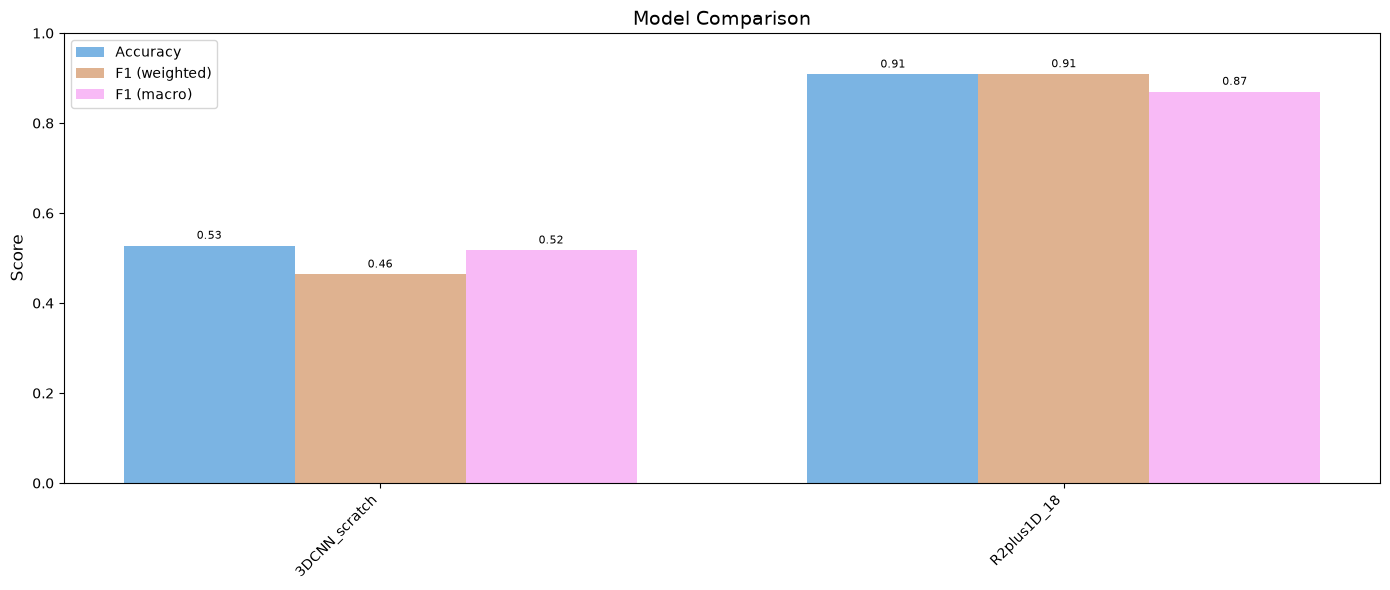


  FINAL MODEL COMPARISON
  Model                       Accuracy     F1 (w)     F1 (m)
  -------------------------------------------------------
  R2plus1D_18                   0.9083     0.9090     0.8699
  3DCNN_scratch                 0.5277     0.4638     0.5173


Model                  Params   Inference FPS
3DCNN_scratch       1,199,821           102.0
R2plus1D_18        31,306,794             7.6


In [22]:
all_results = [results_a, results_b]
compare_models(all_results, save_dir="../results/figures")

print(f"\n{'Model':<16} {'Params':>12} {'Inference FPS':>15}")
print(f"{'3DCNN_scratch':<16} {n_params_a:>12,} {timing_a['fps']:>15.1f}")
print(f"{'R2plus1D_18':<16} {n_params_b_total:>12,} {timing_b['fps']:>15.1f}")